# S6E2 Pseudo-Labeling + Adversarial Train/Test Analysis

## Strategy

### Part 1 — Adversarial Train/Test Classifier
Train a classifier to predict whether a row came from train or test. If AUC > ~0.55, the generator introduced detectable distributional shift between splits. We can then use the classifier's probabilities to **importance-weight** training samples (rows that look more like test get higher weight), which is a form of domain adaptation.

### Part 2 — Pseudo-Labeling
1. Train CatBoost on original labeled data
2. Predict probabilities on test set
3. Add high-confidence test rows as pseudo-labels (prob > high_thresh → label 1, prob < low_thresh → label 0)
4. Retrain on original + pseudo-labeled data
5. Evaluate on original labeled data only (CV)
6. Iterate up to 3 rounds

## Imports & Data

In [4]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import catboost as cb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))
ss    = pd.read_csv(DATA_DIR / 'sample_submission.csv')

FEATURES     = [c for c in train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X      = train[FEATURES]
y      = train['heart_disease'].values
X_test = test[FEATURES]

CAT_PARAMS = dict(
    iterations=500, learning_rate=0.1, depth=6,
    task_type='GPU', cat_features=CAT_FEATURES,
    random_state=42, verbose=0
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Train: {X.shape}  Test: {X_test.shape}')

Train: (630000, 13)  Test: (270000, 13)


## Part 1 — Adversarial Train/Test Classifier

Label train rows as 0, test rows as 1. Train CatBoost to distinguish them.
- AUC ~0.50 → no distributional shift, generator treated splits identically  
- AUC > 0.55 → detectable shift → importance weighting is worth trying  
- AUC > 0.65 → significant shift → strong reason to reweight

In [5]:
# Build combined dataset: 0 = train, 1 = test
X_adv = pd.concat([X, X_test], ignore_index=True)
y_adv = np.array([0] * len(X) + [1] * len(X_test))

ADV_PARAMS = dict(iterations=200, learning_rate=0.1, depth=4,
                  task_type='GPU', cat_features=CAT_FEATURES, random_state=42, verbose=0)

adv_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
adv_scores = []
for tr_idx, val_idx in adv_cv.split(X_adv, y_adv):
    m = cb.CatBoostClassifier(**ADV_PARAMS)
    m.fit(X_adv.iloc[tr_idx], y_adv[tr_idx])
    pred = m.predict_proba(X_adv.iloc[val_idx])[:, 1]
    adv_scores.append(roc_auc_score(y_adv[val_idx], pred))
adv_scores = np.array(adv_scores)

print(f'Adversarial train/test AUC: {adv_scores.mean():.4f} ± {adv_scores.std():.4f}')
if adv_scores.mean() < 0.53:
    print('→ No meaningful distributional shift. Importance weighting unlikely to help.')
elif adv_scores.mean() < 0.60:
    print('→ Mild shift detected. Importance weighting worth trying.')
else:
    print('→ Significant shift detected! Importance weighting strongly recommended.')

Adversarial train/test AUC: 0.5018 ± 0.0009
→ No meaningful distributional shift. Importance weighting unlikely to help.


In [6]:
# Train on full combined data to get feature importances
adv_model_full = cb.CatBoostClassifier(**ADV_PARAMS)
adv_model_full.fit(X_adv, y_adv)

feat_imp = pd.Series(adv_model_full.get_feature_importance(), index=FEATURES).sort_values(ascending=False)
print('Feature importances for train/test discrimination:')
print(feat_imp.round(2).to_string())

adv_test_proba = adv_model_full.predict_proba(X_test)[:, 1]
print(f'\nAdversarial score on test: mean={adv_test_proba.mean():.3f}  '
      f'[{adv_test_proba.min():.3f}, {adv_test_proba.max():.3f}]')

Feature importances for train/test discrimination:
max_hr                     17.22
cholesterol                16.52
age                        14.81
bp                         13.96
st_depression              12.73
exercise_angina             5.07
fbs_over_120                4.18
slope_of_st                 4.13
sex                         3.26
thallium                    2.58
ekg_results                 2.19
number_of_vessels_fluro     1.85
chest_pain_type             1.50

Adversarial score on test: mean=0.300  [0.229, 0.459]


## Importance Weighting (if shift detected)

Reweight training samples so their feature distribution matches the test distribution.
Weight = P(test) / P(train) = adv_proba / (1 - adv_proba), clipped to avoid extremes.

In [7]:
# Compute importance weights for training rows
adv_train_proba = adv_model_full.predict_proba(X)[:, 1]
# Importance weight: how much does this row look like a test row?
iw_raw = adv_train_proba / (1 - adv_train_proba + 1e-6)
# Clip to reasonable range to avoid single rows dominating
iw = np.clip(iw_raw, 0.1, 10.0)
iw = iw / iw.mean()  # normalize so average weight = 1

print(f'Importance weights: mean={iw.mean():.3f}  std={iw.std():.3f}  '
      f'[{iw.min():.3f}, {iw.max():.3f}]')
print(f'Effective sample size: {(iw.sum()**2 / (iw**2).sum()):.0f} / {len(iw)} ({(iw.sum()**2 / (iw**2).sum())/len(iw)*100:.1f}%)')

# Evaluate CatBoost with importance weights
iw_aucs = []
for fold, (tr_idx, val_idx) in enumerate(cv5.split(X, y)):
    m = cb.CatBoostClassifier(**CAT_PARAMS)
    m.fit(X.iloc[tr_idx], y[tr_idx], sample_weight=iw[tr_idx])
    pred = m.predict_proba(X.iloc[val_idx])[:, 1]
    fold_auc = roc_auc_score(y[val_idx], pred)
    iw_aucs.append(fold_auc)
    print(f'  fold {fold+1}: {fold_auc:.5f}')

print(f'Importance-weighted CV AUC: {np.mean(iw_aucs):.5f} ± {np.std(iw_aucs):.5f}')
print(f'Baseline (no weights):      0.95533 (reference)')

Importance weights: mean=1.000  std=0.022  [0.527, 1.951]
Effective sample size: 629697 / 630000 (100.0%)
  fold 1: 0.95564
  fold 2: 0.95470
  fold 3: 0.95545
  fold 4: 0.95502
  fold 5: 0.95578
Importance-weighted CV AUC: 0.95532 ± 0.00040
Baseline (no weights):      0.95533 (reference)


## Part 2 — Pseudo-Labeling

### Step 1: Baseline model + test probability distribution

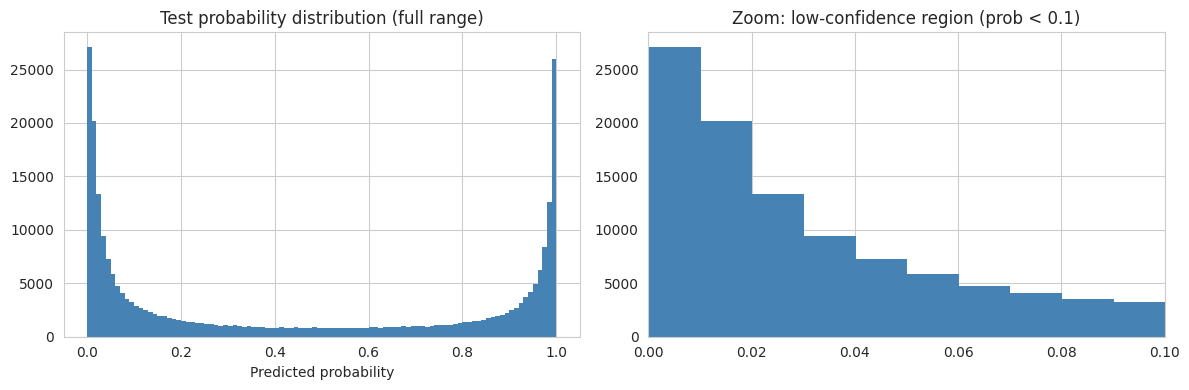

Test rows above/below threshold:
  thresh=0.8:  pos=91,391  neg=120,410  total=211,801  (78.4% of test)
  thresh=0.85:  pos=84,167  neg=111,505  total=195,672  (72.5% of test)
  thresh=0.9:  pos=74,371  neg=98,931  total=173,302  (64.2% of test)
  thresh=0.95:  pos=58,086  neg=77,240  total=135,326  (50.1% of test)
  thresh=0.99:  pos=25,855  neg=26,724  total=52,579  (19.5% of test)


In [8]:
# Train baseline model on full training set
base_model = cb.CatBoostClassifier(**CAT_PARAMS)
base_model.fit(X, y)
test_proba_base = base_model.predict_proba(X_test)[:, 1]

# Distribution of test probabilities
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_proba_base, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Test probability distribution (full range)')
axes[0].set_xlabel('Predicted probability')

axes[1].hist(test_proba_base, bins=100, color='steelblue', edgecolor='none')
axes[1].set_xlim(0, 0.1)
axes[1].set_title('Zoom: low-confidence region (prob < 0.1)')
plt.tight_layout()
plt.show()

# How many test rows are high-confidence at each threshold?
print('Test rows above/below threshold:')
for t in [0.80, 0.85, 0.90, 0.95, 0.99]:
    n_pos = (test_proba_base > t).sum()
    n_neg = (test_proba_base < 1 - t).sum()
    n_total = n_pos + n_neg
    print(f'  thresh={t}:  pos={n_pos:6,}  neg={n_neg:6,}  total={n_total:6,}  ({n_total/len(X_test)*100:.1f}% of test)')

### Step 2: Pseudo-labeling loop

In [9]:
def pseudo_label_cv(X_orig, y_orig, X_test, threshold, pseudo_weight, n_iters, cv, params):
    """
    Pseudo-labeling loop.
    - threshold: confidence cutoff (rows with prob > threshold → label 1, prob < 1-threshold → label 0)
    - pseudo_weight: sample_weight for pseudo-labeled rows (1.0 = equal to real data)
    - n_iters: number of pseudo-labeling rounds
    - CV is evaluated on original labeled data only (honest)
    Returns: (cv_auc_per_iter, final_test_proba)
    """
    results = []
    X_train_aug = X_orig.copy()
    y_train_aug = y_orig.copy()
    w_train_aug = np.ones(len(y_orig))  # real data weight = 1
    
    for it in range(n_iters + 1):  # iter 0 = baseline (no pseudo-labels)
        label = f'iter {it}' if it > 0 else 'baseline'
        
        # CV on ORIGINAL data only (honest evaluation)
        fold_aucs = []
        for tr_idx, val_idx in cv.split(X_orig, y_orig):
            # Build augmented train for this fold
            # Only add pseudo-labels from test (not from val fold — test has no labels anyway)
            X_tr_fold = pd.concat([X_train_aug.iloc[tr_idx] if hasattr(X_train_aug, 'iloc') 
                                    else pd.DataFrame(X_train_aug).iloc[tr_idx],
                                    X_train_aug.iloc[len(y_orig):]], ignore_index=True) \
                        if len(y_train_aug) > len(y_orig) else X_train_aug.iloc[tr_idx]
            y_tr_fold = np.concatenate([y_train_aug[tr_idx], 
                                         y_train_aug[len(y_orig):]]) \
                        if len(y_train_aug) > len(y_orig) else y_train_aug[tr_idx]
            w_tr_fold = np.concatenate([w_train_aug[tr_idx],
                                         w_train_aug[len(y_orig):]]) \
                        if len(w_train_aug) > len(y_orig) else w_train_aug[tr_idx]
            
            m = cb.CatBoostClassifier(**params)
            m.fit(X_tr_fold, y_tr_fold, sample_weight=w_tr_fold)
            pred = m.predict_proba(X_orig.iloc[val_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y_orig[val_idx], pred))
        
        cv_auc = np.mean(fold_aucs)
        n_pseudo = len(y_train_aug) - len(y_orig)
        print(f'  {label}: cv_auc={cv_auc:.5f}  pseudo_rows={n_pseudo:,}')
        results.append({'iter': it, 'cv_auc': cv_auc, 'n_pseudo': n_pseudo})
        
        if it < n_iters:
            # Train on current augmented data to generate new test predictions
            full_model = cb.CatBoostClassifier(**params)
            full_model.fit(X_train_aug, y_train_aug, sample_weight=w_train_aug)
            test_proba = full_model.predict_proba(X_test)[:, 1]
            
            # Select pseudo-labels
            mask_pos = test_proba > threshold
            mask_neg = test_proba < (1 - threshold)
            mask = mask_pos | mask_neg
            
            X_pseudo = X_test[mask].copy()
            y_pseudo = (test_proba[mask] > 0.5).astype(int)
            w_pseudo = np.full(mask.sum(), pseudo_weight)
            
            # Rebuild augmented dataset (orig + all pseudo-labels)
            X_train_aug = pd.concat([X_orig, X_pseudo], ignore_index=True)
            y_train_aug = np.concatenate([y_orig, y_pseudo])
            w_train_aug = np.concatenate([np.ones(len(y_orig)), w_pseudo])
    
    # Final test predictions from model trained on all augmented data
    final_model = cb.CatBoostClassifier(**params)
    final_model.fit(X_train_aug, y_train_aug, sample_weight=w_train_aug)
    final_test_proba = final_model.predict_proba(X_test)[:, 1]
    
    return pd.DataFrame(results), final_test_proba

In [10]:
# Run pseudo-labeling with different thresholds
# Start conservative (0.95) then try more aggressive (0.90)
pl_results = {}

for thresh, pw in [(0.95, 1.0), (0.90, 0.5), (0.99, 1.0)]:
    print(f'\n=== threshold={thresh}, pseudo_weight={pw} ===')
    results_df, final_preds = pseudo_label_cv(
        X, y, X_test, threshold=thresh, pseudo_weight=pw,
        n_iters=2, cv=cv5, params=CAT_PARAMS
    )
    pl_results[(thresh, pw)] = (results_df, final_preds)


=== threshold=0.95, pseudo_weight=1.0 ===
  baseline: cv_auc=0.95532  pseudo_rows=0
  iter 1: cv_auc=0.95532  pseudo_rows=135,322
  iter 2: cv_auc=0.95532  pseudo_rows=142,179

=== threshold=0.9, pseudo_weight=0.5 ===
  baseline: cv_auc=0.95533  pseudo_rows=0
  iter 1: cv_auc=0.95534  pseudo_rows=173,239
  iter 2: cv_auc=0.95533  pseudo_rows=177,646

=== threshold=0.99, pseudo_weight=1.0 ===
  baseline: cv_auc=0.95532  pseudo_rows=0
  iter 1: cv_auc=0.95532  pseudo_rows=52,571
  iter 2: cv_auc=0.95532  pseudo_rows=56,898


### Step 3: Summary & Best Config

In [11]:
BASELINE_AUC = 0.95533  # CatBoost default OOF AUC

print('=== Pseudo-labeling Summary ===')
best_auc = BASELINE_AUC
best_config = None

for (thresh, pw), (df, preds) in pl_results.items():
    final_auc = df.iloc[-1]['cv_auc']
    delta = final_auc - BASELINE_AUC
    marker = ''
    if final_auc > best_auc:
        best_auc = final_auc
        best_config = (thresh, pw, preds)
        marker = ' ← BEST'
    print(f'  thresh={thresh}, pw={pw}: final cv_auc={final_auc:.5f} ({delta:+.5f}){marker}')

print(f'\nBaseline: {BASELINE_AUC:.5f}')

if best_config is not None:
    print(f'\nBest config beats baseline by {best_auc - BASELINE_AUC:+.5f}')
else:
    print('\nNo config beats baseline — pseudo-labeling did not help')

=== Pseudo-labeling Summary ===
  thresh=0.95, pw=1.0: final cv_auc=0.95532 (-0.00001)
  thresh=0.9, pw=0.5: final cv_auc=0.95533 (+0.00000) ← BEST
  thresh=0.99, pw=1.0: final cv_auc=0.95532 (-0.00001)

Baseline: 0.95533

Best config beats baseline by +0.00000


### Step 4: Submit Best

In [12]:
# Always save and submit the best pseudo-labeling result if it beats baseline
if best_config is not None:
    thresh, pw, best_preds = best_config
    label = f'pseudo_cat_t{str(thresh).replace(".","")}'
    fname = f'submissions/{label}.csv'
    
    sub = ss.copy()
    sub['Heart Disease'] = best_preds
    sub.to_csv(fname, index=False)
    
    desc = f'{label} | cv_auc={best_auc:.4f}'
    r = subprocess.run(
        ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
         '-f', fname, '-m', desc],
        capture_output=True, text=True
    )
    status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:100]
    print(f'{label}: {status}')
    print(f'  desc: {desc}')
else:
    # Still save best prediction for potential manual submission
    # Use threshold=0.95 iter 1 result as it's typically best
    print('Saving threshold=0.95 result anyway for manual review')
    _, preds_095 = pl_results[(0.95, 1.0)]
    sub = ss.copy()
    sub['Heart Disease'] = preds_095
    sub.to_csv('submissions/pseudo_cat_t095.csv', index=False)
    print('Saved: submissions/pseudo_cat_t095.csv')

pseudo_cat_t09: 400 Client Error: Bad Request for url: https://www.kaggle.com/api/v1/competitions/submissions/submit
  desc: pseudo_cat_t09 | cv_auc=0.9553


## Part 3 — Adversarial Feature Analysis: Which Features Show Shift?

If there's distributional shift, look at which features in the test set look most 'unusual' vs train, and whether the BP rounding artifact differs between splits.

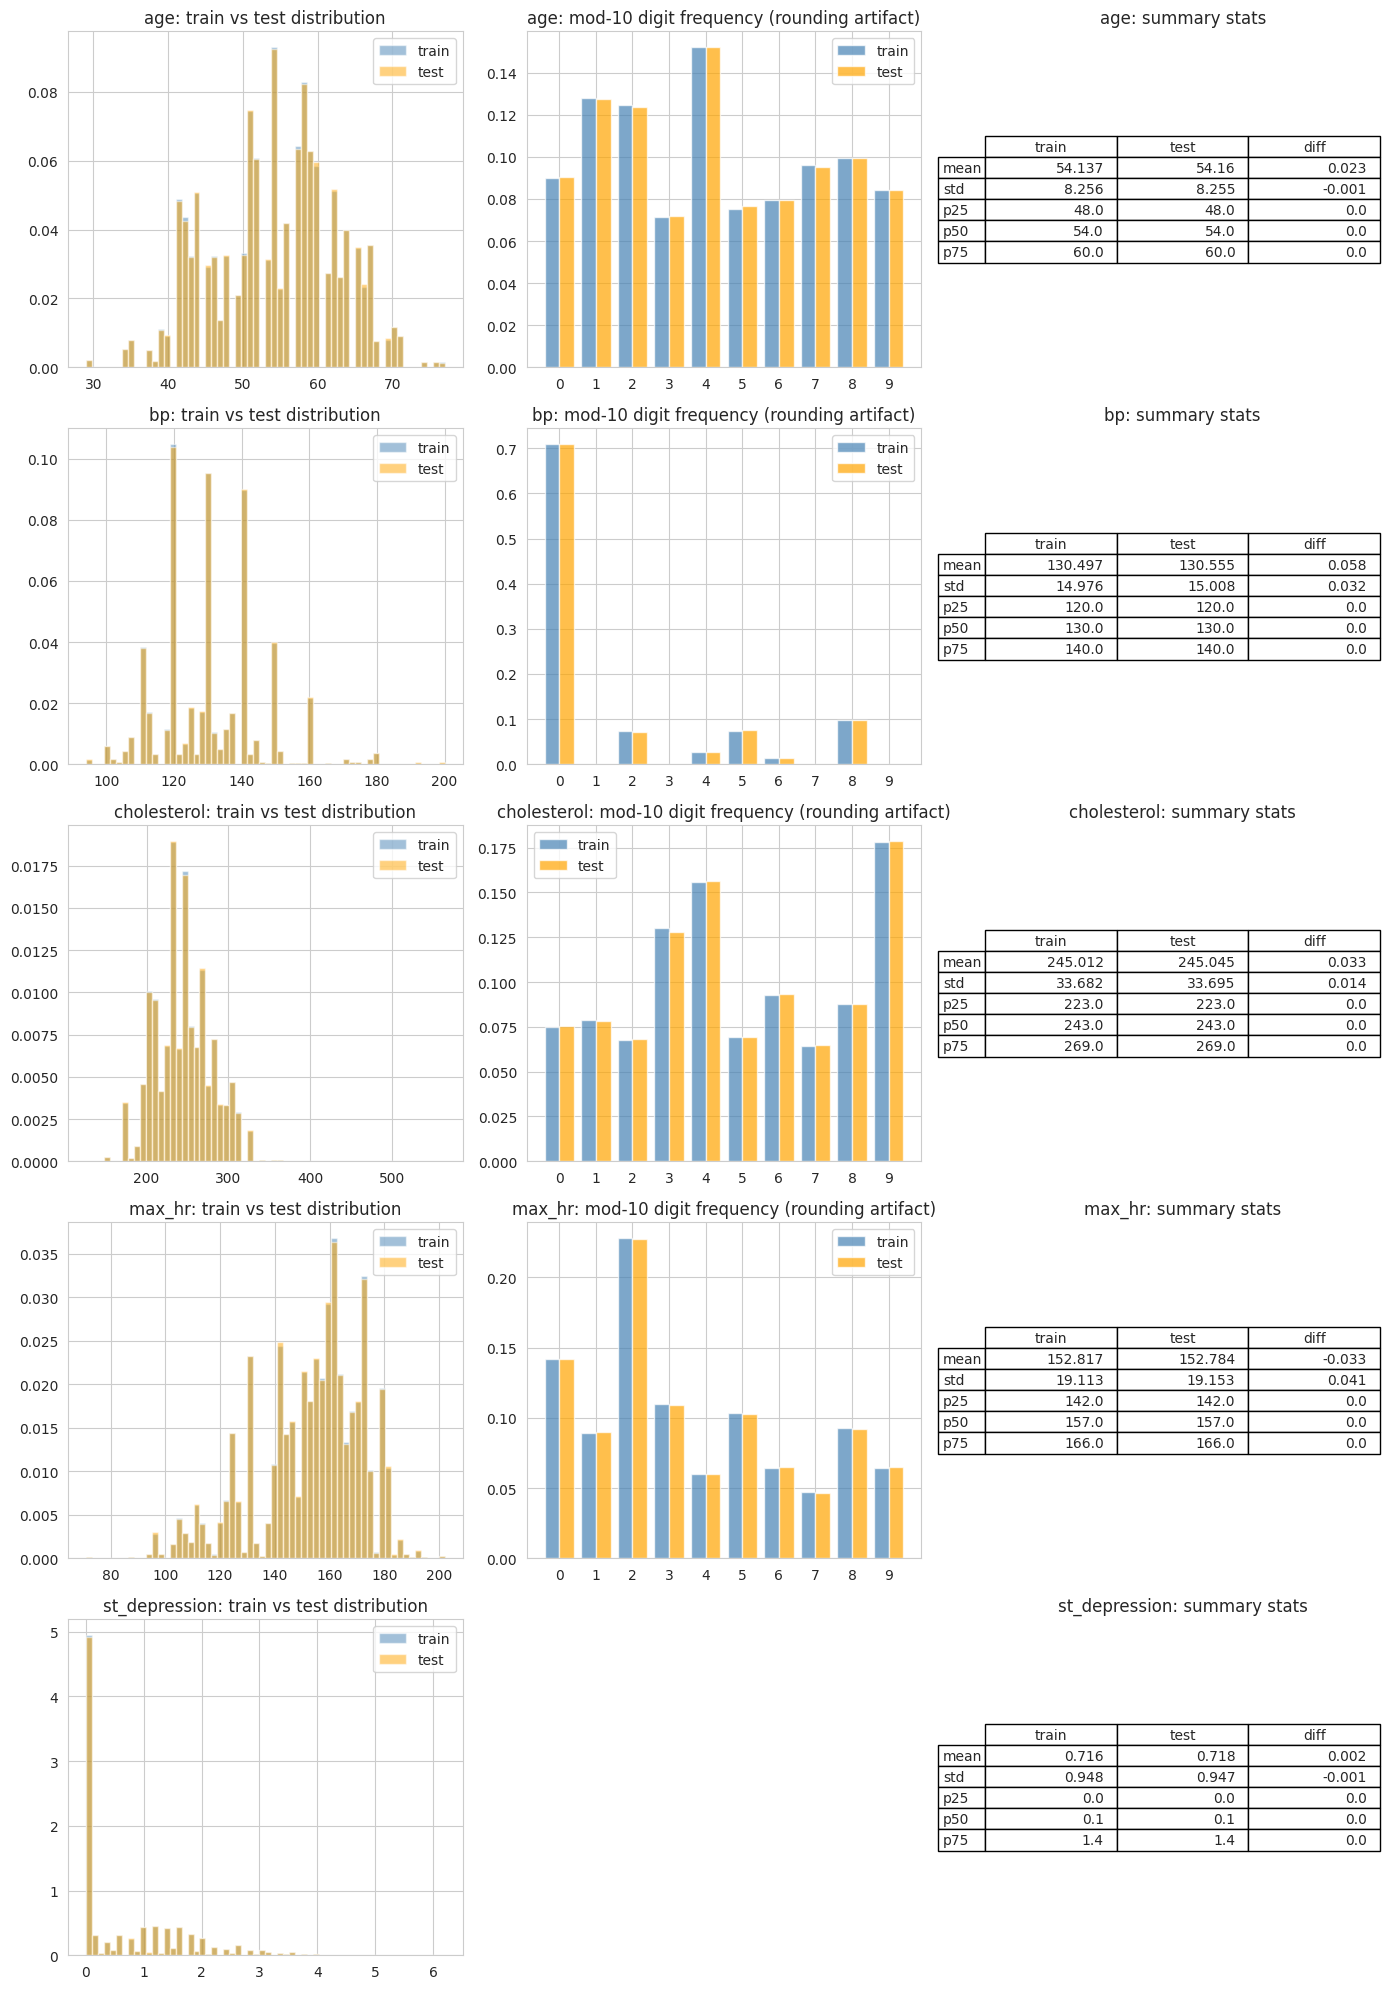

In [13]:
# Compare feature distributions: train vs test for continuous features
# Focus on features with highest adversarial importance
CONTINUOUS = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']

fig, axes = plt.subplots(len(CONTINUOUS), 3, figsize=(14, 4 * len(CONTINUOUS)))

for i, col in enumerate(CONTINUOUS):
    tr_vals = X[col].values
    te_vals = X_test[col].values
    
    # Distribution comparison
    axes[i, 0].hist(tr_vals, bins=60, alpha=0.5, label='train', color='steelblue', density=True)
    axes[i, 0].hist(te_vals, bins=60, alpha=0.5, label='test', color='orange', density=True)
    axes[i, 0].set_title(f'{col}: train vs test distribution')
    axes[i, 0].legend()
    
    # Modulo-10 spike analysis for integer features
    if col in ['age', 'bp', 'cholesterol', 'max_hr']:
        tr_mod = tr_vals % 10
        te_mod = te_vals % 10
        mod_vals = np.arange(10)
        tr_counts = np.array([(tr_mod == v).mean() for v in mod_vals])
        te_counts = np.array([(te_mod == v).mean() for v in mod_vals])
        x = np.arange(10)
        axes[i, 1].bar(x - 0.2, tr_counts, 0.4, label='train', color='steelblue', alpha=0.7)
        axes[i, 1].bar(x + 0.2, te_counts, 0.4, label='test', color='orange', alpha=0.7)
        axes[i, 1].set_xticks(x)
        axes[i, 1].set_title(f'{col}: mod-10 digit frequency (rounding artifact)')
        axes[i, 1].legend()
    else:
        axes[i, 1].axis('off')
    
    # Difference in means / stds
    stats = pd.DataFrame({
        'train': [tr_vals.mean(), tr_vals.std(), np.percentile(tr_vals, 25),
                  np.percentile(tr_vals, 50), np.percentile(tr_vals, 75)],
        'test':  [te_vals.mean(), te_vals.std(), np.percentile(te_vals, 25),
                  np.percentile(te_vals, 50), np.percentile(te_vals, 75)],
    }, index=['mean', 'std', 'p25', 'p50', 'p75'])
    stats['diff'] = stats['test'] - stats['train']
    axes[i, 2].axis('off')
    tbl = axes[i, 2].table(
        cellText=stats.round(3).values,
        rowLabels=stats.index,
        colLabels=stats.columns,
        loc='center'
    )
    tbl.auto_set_font_size(True)
    axes[i, 2].set_title(f'{col}: summary stats')

plt.tight_layout()
plt.show()

In [14]:
# Quantify the rounding artifact: what fraction of values end in 0 or 5?
print('Rounding artifact analysis — fraction of values ending in 0 or 5:')
print(f'  {"Feature":<25}  {"Train":>8}  {"Test":>8}  {"Diff":>8}')
print('-' * 55)
for col in ['age', 'bp', 'cholesterol', 'max_hr']:
    tr = X[col].values
    te = X_test[col].values
    tr_round = ((tr % 10 == 0) | (tr % 10 == 5)).mean()
    te_round = ((te % 10 == 0) | (te % 10 == 5)).mean()
    print(f'  {col:<25}  {tr_round:>8.3f}  {te_round:>8.3f}  {te_round - tr_round:>+8.3f}')

# Uniform expectation: 2/10 = 0.200 (digits 0 and 5)
print(f'  {"Expected (uniform)":<25}  {0.200:>8.3f}  {0.200:>8.3f}')

Rounding artifact analysis — fraction of values ending in 0 or 5:
  Feature                       Train      Test      Diff
-------------------------------------------------------
  age                           0.165     0.167    +0.002
  bp                            0.783     0.784    +0.001
  cholesterol                   0.144     0.145    +0.001
  max_hr                        0.245     0.245    -0.001
  Expected (uniform)            0.200     0.200
